# 1. Tải dữ liệu và trích xuất đặc trưng thời gian

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tùy chỉnh giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- KHỐI 1: TẢI DỮ LIỆU & TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN ---")

# 1. Tải file dữ liệu sạch
clean_data_path = r'../../data/yellow_tripdata_2026-01_CLEANED.parquet'
df = pd.read_parquet(clean_data_path)
print(f"Đã tải thành công {len(df):,} dòng dữ liệu sạch.")

# 2. Trích xuất (Feature Engineering) các mốc thời gian
# Lưu ý: Cột tpep_pickup_datetime hiện tại đã được pandas hiểu là định dạng datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek # 0=Thứ 2, 6=Chủ nhật
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

# Map tên Thứ trong tuần cho dễ đọc khi vẽ biểu đồ
day_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df['day_name'] = df['pickup_dayofweek'].map(day_names)

# Phân loại Ngày thường (Weekday) vs Cuối tuần (Weekend)
df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Hiển thị thử 5 dòng kết quả để nghiệm thu
print("\n=> 5 dòng đầu của các cột thời gian vừa tạo:")
display(df[['tpep_pickup_datetime', 'pickup_hour', 'day_name', 'is_weekend', 'pickup_date']].head())


--- KHỐI 1: TẢI DỮ LIỆU & TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN ---
Đã tải thành công 3,499,217 dòng dữ liệu sạch.

=> 5 dòng đầu của các cột thời gian vừa tạo:


,tpep_pickup_datetime,pickup_hour,day_name,is_weekend,pickup_date
0,2026-01-01 00:54:04,0,Thứ 5,Weekday,2026-01-01
1,2026-01-01 00:15:22,0,Thứ 5,Weekday,2026-01-01
2,2026-01-01 00:47:11,0,Thứ 5,Weekday,2026-01-01
3,2026-01-01 00:17:54,0,Thứ 5,Weekday,2026-01-01
4,2026-01-01 00:34:14,0,Thứ 5,Weekday,2026-01-01


In [2]:
# In ra danh sách toàn bộ các cột hiện có trong Dataframe
print("DANH SÁCH CÁC CỘT HIỆN TẠI:")
print(df.columns.tolist())

# Hiển thị tất cả các cột của 3 dòng đầu tiên để soi kỹ dữ liệu
pd.set_option('display.max_columns', None) # Lệnh này ép Jupyter hiện TẤT CẢ các cột (không bị ẩn bằng dấu ...)
display(df.head(3))



DANH SÁCH CÁC CỘT HIỆN TẠI:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'pu_LocationID', 'pu_Borough', 'pu_Zone', 'pu_service_zone', 'do_LocationID', 'do_Borough', 'do_Zone', 'do_service_zone', 'vendor_name', 'ratecode_name', 'hour_of_day', 'day_of_week', 'trip_duration_minutes', 'speed_mph', 'pickup_hour', 'pickup_dayofweek', 'pickup_date', 'day_name', 'is_weekend']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pu_LocationID,pu_Borough,pu_Zone,pu_service_zone,do_LocationID,do_Borough,do_Zone,do_service_zone,vendor_name,ratecode_name,hour_of_day,day_of_week,trip_duration_minutes,speed_mph,pickup_hour,pickup_dayofweek,pickup_date,day_name,is_weekend
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,239,Manhattan,Upper West Side South,Yellow Zone,238,Manhattan,Upper West Side North,Yellow Zone,Curb Mobility,Standard rate,0,3,5.55,10.486486,0,3,2026-01-01,Thứ 5,Weekday
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,142,Manhattan,Lincoln Square East,Yellow Zone,209,Manhattan,Seaport,Yellow Zone,Curb Mobility,Standard rate,0,3,42.80,7.822430,0,3,2026-01-01,Thứ 5,Weekday
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,144,Manhattan,Little Italy/NoLiTa,Yellow Zone,137,Manhattan,Kips Bay,Yellow Zone,Curb Mobility,Standard rate,0,3,13.60,10.279412,0,3,2026-01-01,Thứ 5,Weekday


In [3]:
# Danh sách các cột bị trùng lặp logic
cols_to_drop = ['pu_LocationID', 'do_LocationID', 'hour_of_day', 'day_of_week']

# Lệnh XÓA (Drop)
df = df.drop(columns=cols_to_drop)

print(f"Đã xóa thành công {len(cols_to_drop)} cột bị trùng lặp!")
print(f"Số cột hiện tại đã gọn gàng hơn: {len(df.columns)} cột.")


Đã xóa thành công 4 cột bị trùng lặp!
Số cột hiện tại đã gọn gàng hơn: 35 cột.


# 2. Phân tích khung giờ trong ngày

--- KHỐI 2: PHÂN TÍCH THEO KHUNG GIỜ TRONG NGÀY (HOUR-OF-DAY) ---


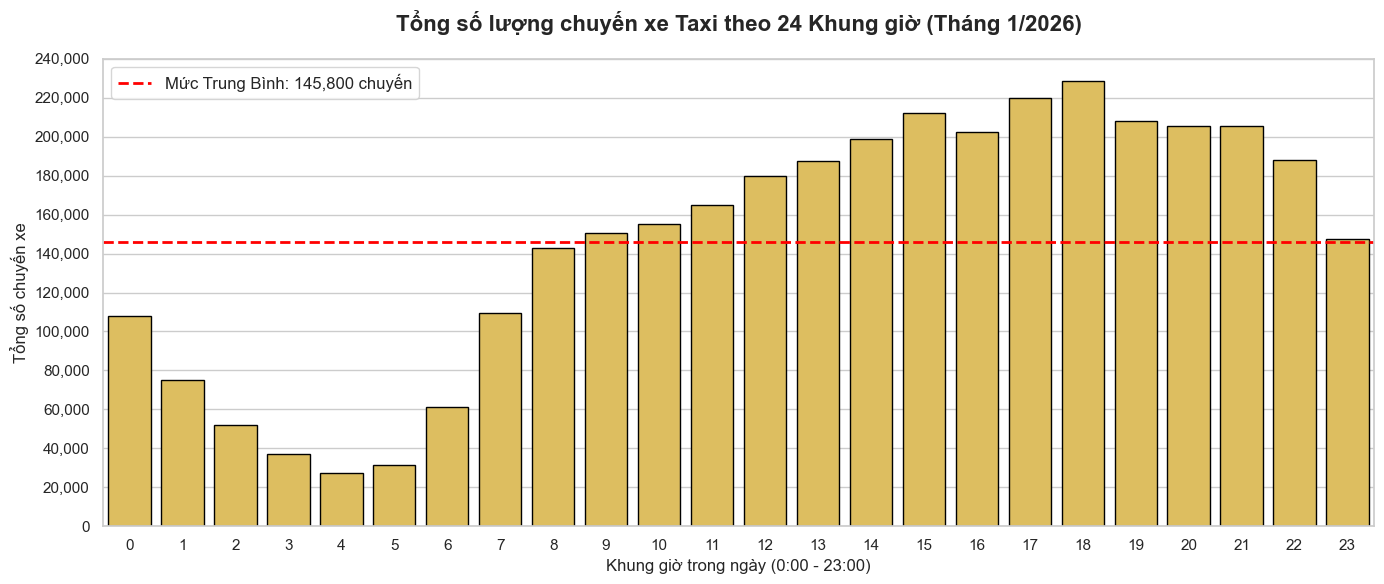

In [4]:
print("--- KHỐI 2: PHÂN TÍCH THEO KHUNG GIỜ TRONG NGÀY (HOUR-OF-DAY) ---")

# Tính tổng số chuyến xe theo từng giờ
hourly_counts = df.groupby('pickup_hour').size().reset_index(name='trip_count')

# Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ Cột (Barplot) màu Vàng đặc trưng của Taxi
sns.barplot(data=hourly_counts, x='pickup_hour', y='trip_count', color='#F2C84B', edgecolor='black')

# Trang trí tiêu đề và trục
plt.title('Tổng số lượng chuyến xe Taxi theo 24 Khung giờ (Tháng 1/2026)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Khung giờ trong ngày (0:00 - 23:00)', fontsize=12)
plt.ylabel('Tổng số chuyến xe', fontsize=12)
plt.xticks(range(0, 24))
plt.yticks(range(0, int(hourly_counts['trip_count'].max()) + 20000, 20000))

# Thêm 1 đường gạch ngang màu đỏ đứt nét để thể hiện Mức Trung bình (Average)
avg_trips = hourly_counts['trip_count'].mean()
plt.axhline(avg_trips, color='red', linestyle='--', linewidth=2, label=f'Mức Trung Bình: {int(avg_trips):,} chuyến')
plt.legend(fontsize=12)

# Định dạng nhãn trục Y có dấu phẩy (vd: 100,000)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Peak Hours (Giờ cao điểm):** Nhu cầu gọi xe tăng mạnh từ 15h và đạt đỉnh vào khung **17h - 18h tối** (Khoảng 240,000 chuyến/tháng). Đây là lúc người dân tan tầm, đi ăn uống, giải trí.
> * **Off-peak Hours (Giờ thấp điểm):** Từ **2h - 5h sáng**, lượng gọi xe chạm đáy.
> * **Morning Commute (Đi làm buổi sáng):** Có sự gia tăng rõ rệt vào **8h - 9h sáng**, tuy nhiên không cao bằng đỉnh buổi tối. (Lý do: Sáng đi tàu điện ngầm cho đỡ tắc đường, tối đi Taxi cho thoải mái).


# 3. Phân tích theo thứ trong tuần

--- KHỐI 3: PHÂN TÍCH THEO THỨ TRONG TUẦN (DAY-OF-WEEK) - BẢN BOXPLOT ---


C:\Users\minhh\AppData\Local\Temp\ipykernel_30144\358234064.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_day_counts, x='day_name', y='trips', ax=ax[0], palette=['#4A90E2']*5 + ['#F5A623']*2)
C:\Users\minhh\AppData\Local\Temp\ipykernel_30144\358234064.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily_trips, x='is_weekend', y='trips', ax=ax[1], palette={'Weekday': '#4A90E2', 'Weekend': '#F5A623'})


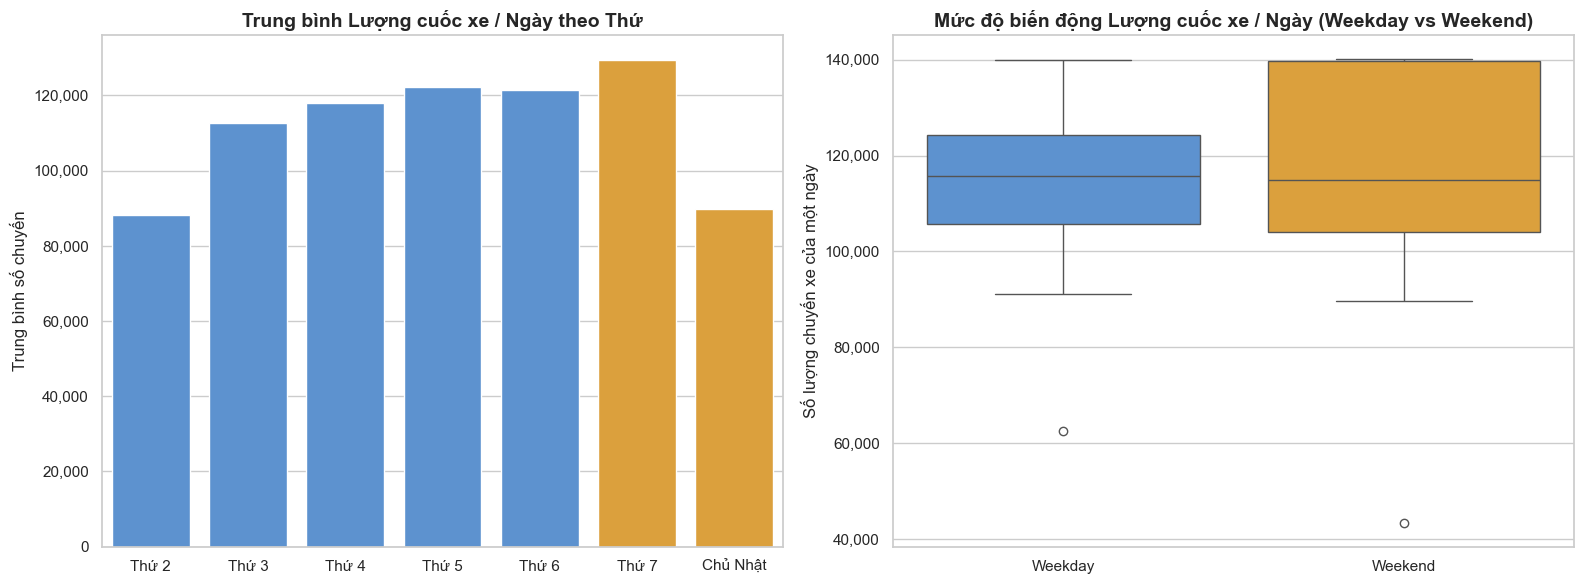

In [10]:
print("--- KHỐI 3: PHÂN TÍCH THEO THỨ TRONG TUẦN (DAY-OF-WEEK) - BẢN BOXPLOT ---")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tính TRUNG BÌNH số chuyến theo từng Thứ 
daily_trips = df.groupby(['pickup_date', 'day_name', 'is_weekend']).size().reset_index(name='trips')
order_days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
avg_day_counts = daily_trips.groupby('day_name')['trips'].mean().reindex(order_days).reset_index()

sns.barplot(data=avg_day_counts, x='day_name', y='trips', ax=ax[0], palette=['#4A90E2']*5 + ['#F5A623']*2)
ax[0].set_title('Trung bình Lượng cuốc xe / Ngày theo Thứ', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Trung bình số chuyến', fontsize=12)
ax[0].set_xlabel('')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 2. Biểu đồ Hộp (Boxplot): So sánh độ biến động (Variance) giữa Ngày thường và Cuối tuần
sns.boxplot(data=daily_trips, x='is_weekend', y='trips', ax=ax[1], palette={'Weekday': '#4A90E2', 'Weekend': '#F5A623'})
ax[1].set_title('Mức độ biến động Lượng cuốc xe / Ngày (Weekday vs Weekend)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Số lượng chuyến xe của một ngày', fontsize=12)
ax[1].set_xlabel('')
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


--- KHỐI TẶNG THÊM: BẢN ĐỒ NHIỆT (HEATMAP) GIỜ VÀ THỨ ---


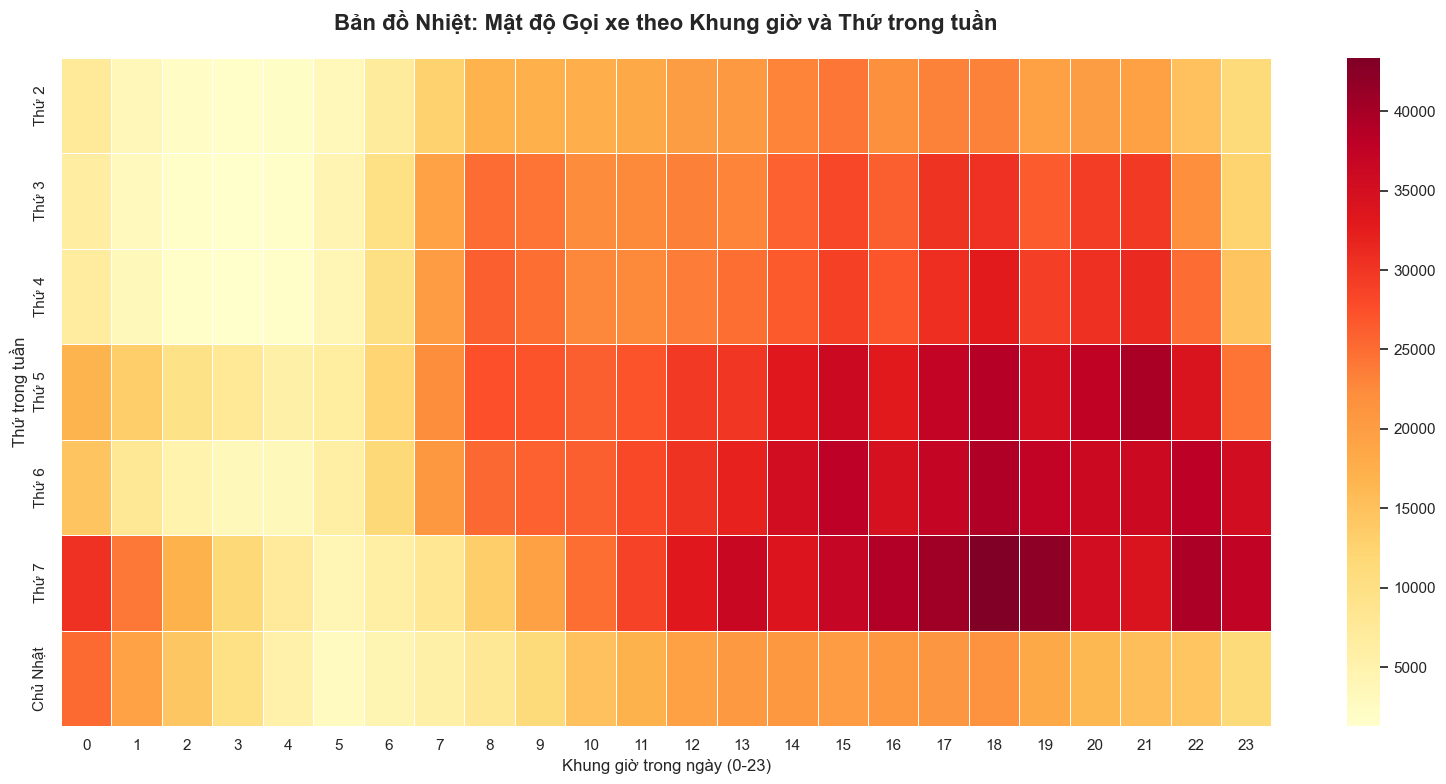

In [8]:
print("--- KHỐI TẶNG THÊM: BẢN ĐỒ NHIỆT (HEATMAP) GIỜ VÀ THỨ ---")

# Tạo bảng ma trận: Hàng là Thứ, Cột là Giờ, Giá trị là Số chuyến xe
heatmap_data = df.groupby(['day_name', 'pickup_hour']).size().unstack()

# Sắp xếp lại thứ tự các ngày trong tuần cho chuẩn
order_days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
heatmap_data = heatmap_data.reindex(order_days)

plt.figure(figsize=(16, 8))
# Vẽ Heatmap dùng dải màu vàng - cam - đỏ (YlOrRd)
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=.5, fmt=".0f")

plt.title('Bản đồ Nhiệt: Mật độ Gọi xe theo Khung giờ và Thứ trong tuần', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Khung giờ trong ngày (0-23)', fontsize=12)
plt.ylabel('Thứ trong tuần', fontsize=12)

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Sự bấp bênh của Cuối tuần (Dựa trên Boxplot):** Nhu cầu gọi xe vào Cuối tuần vô cùng rủi ro và biến động mạnh (biểu hiện qua hộp màu cam giãn rất rộng). Cụ thể, Thứ 7 là ngày "Vua" (đạt đỉnh cao nhất tuần), nhưng ngay hôm sau Chủ Nhật lại rơi xuống mức thấp nhất tuần. Trong khi đó, Ngày thường (T2-T6) có lượng khách ổn định và dễ lên kế hoạch điều phối xe hơn.
> * **Tự động nhận diện Thời tiết cực đoan:** Biểu đồ Hộp đã tự động tìm ra 2 điểm ngoại lệ (Outliers) nằm tít dưới đáy do bị tác động bởi Bão tuyết: Chủ Nhật (43k chuyến) và Thứ 2 (62k chuyến). 
> * **Các thời điểm nóng lộ diện (Dựa trên Heatmap):** Nhu cầu không rải đều mà bùng nổ cục bộ thành một khối đỏ rực vào **chiều tối Thứ 5, Thứ 6 và Thứ 7** (từ 18h - 22h). Ngược lại, khung giờ sáng T7, CN và gần như cả ngày Chủ Nhật vắng vẻ lạ thường do xu hướng ở nhà tĩnh dưỡng của người dân New York.


# 4. Phân tích xu hướng theo ngày

--- KHỐI 4: PHÂN TÍCH XU HƯỚNG THEO NGÀY (DAILY TREND - UPDATE THEO SỰ TINH MẮT CỦA USER) ---


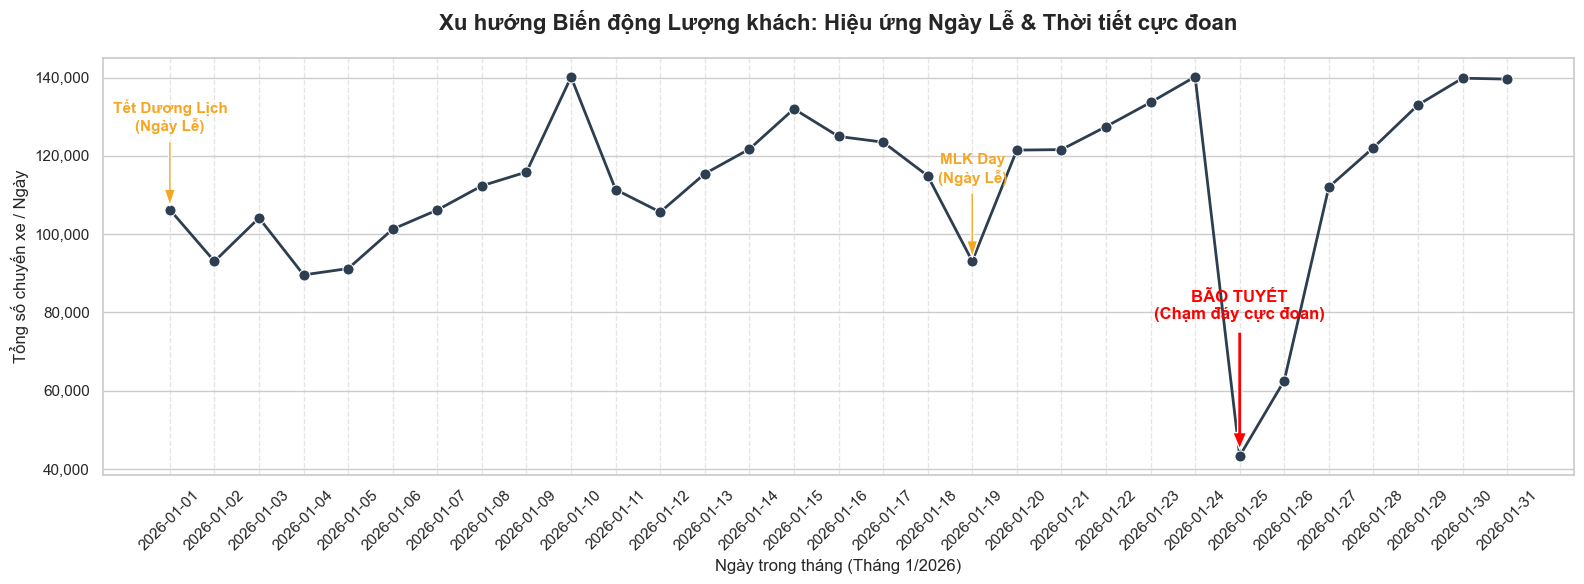

In [9]:
import datetime

print("--- KHỐI 4: PHÂN TÍCH XU HƯỚNG THEO NGÀY (DAILY TREND - UPDATE THEO SỰ TINH MẮT CỦA USER) ---")

daily_trend = df.groupby('pickup_date').size().reset_index(name='trip_count')
plt.figure(figsize=(16, 6))
sns.lineplot(data=daily_trend, x='pickup_date', y='trip_count', marker='o', markersize=8, linewidth=2, color='#2C3E50')

# 1. Gắn nhãn 2 ngày Lễ chính thức
holidays = [datetime.date(2026, 1, 1), datetime.date(2026, 1, 19)]
holiday_names = ['Tết Dương Lịch', 'MLK Day']
for holiday, name in zip(holidays, holiday_names):
    if holiday in daily_trend['pickup_date'].values:
        holiday_trips = daily_trend[daily_trend['pickup_date'] == holiday]['trip_count'].values[0]
        plt.annotate(f'{name}\n(Ngày Lễ)', xy=(holiday, holiday_trips), xytext=(holiday, holiday_trips + 20000),
                     arrowprops=dict(facecolor='#F5A623', shrink=0.05, width=2, headwidth=8),
                     fontsize=11, color='#F5A623', weight='bold', ha='center')

# 2. Gắn nhãn BÃO TUYẾT (ANOMALY) vào vực thẳm ngày 25/01 (Theo phát hiện của bạn)
blizzard_date = datetime.date(2026, 1, 25)
if blizzard_date in daily_trend['pickup_date'].values:
    blizzard_trips = daily_trend[daily_trend['pickup_date'] == blizzard_date]['trip_count'].values[0]
    plt.annotate('BÃO TUYẾT\n(Chạm đáy cực đoan)', xy=(blizzard_date, blizzard_trips), xytext=(blizzard_date, blizzard_trips + 35000),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=3, headwidth=10),
                 fontsize=12, color='red', weight='bold', ha='center')

plt.title('Xu hướng Biến động Lượng khách: Hiệu ứng Ngày Lễ & Thời tiết cực đoan', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ngày trong tháng (Tháng 1/2026)', fontsize=12)
plt.ylabel('Tổng số chuyến xe / Ngày', fontsize=12)
plt.xticks(daily_trend['pickup_date'], rotation=45)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Holiday Effect (Hiệu ứng Ngày Lễ):** Lượng khách sụt giảm cực mạnh vào ngày Tết Dương Lịch (01/01) và Lễ Martin Luther King Jr (19/01). Người dân hạn chế đi lại nội đô.
> * **Thời tiết cực đoan:** Sự kiện bão tuyết chạm đáy vào ngày 25/01 khiến giao thông gần như tê liệt, đánh tụt sản lượng xuống mức thấp nhất tháng (~43,000 chuyến).
> * **Chu kỳ tuần hoàn (Weekly Seasonality):** Nếu loại trừ các sự kiện bất thường, biểu đồ luôn có nhịp đập tạo "Đỉnh" cực kỳ đều đặn vào các ngày cuối tuần (Thứ 5, Thứ 6, Thứ 7) - Ví dụ như các ngày 10/01, 15/01, 24/01, 30/01.
